# DATA PREPARATION

In [1]:
from math import *
from time import *
from matplotlib.pyplot import *
from numpy import * 
from collections import defaultdict
from sklearn.neighbors import KDTree as SkKDTtree
import datetime
from numpy.linalg import *
import heapq
import builtins

def loadPoints(file):
    #load file
    X, Y, Z = [], [], []
    
    with open(file) as f:
        
        for line in f:
            x, y, z = line.split('\t')
            
            X.append(float(x))
            Y.append(float(y))
            Z.append(float(z))
    
    X = np.array(X)
    Y = np.array(Y)
    Z = np.array(Z)
    return X, Y, Z

def drawPoints(X, Y, Z, bx, transp = 0.2):
    # create figure
    fig = figure()
    ax = axes(projection = '3d')
    ax.set_aspect('equal')

    #compute sphere scale: 1 pix = 25.4 mm
    scale = 1
    if bx > 0:
        scale = int(bx * bx * 40 * 40)
        
    #plot points
    ax.scatter(X, Y, Z, s=scale, alpha = transp)

    show()
    

In [2]:
X, Y, Z = loadPoints('tree_18.txt')
'Number of points:', len(X)


('Number of points:', 25737)

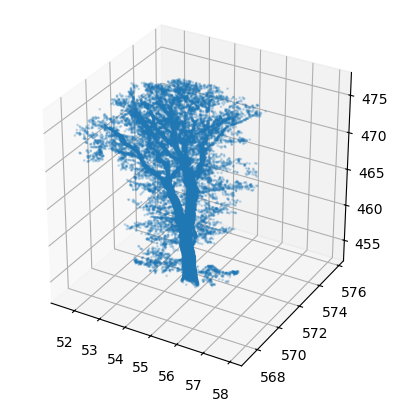

In [3]:
drawPoints(X, Y, Z, 0, 0.2)

# 1. Brute-force nearest neighbor search

In [4]:
def getDensityNN(X, Y, Z):
    n = len(X)
    distances = np.zeros(n)

    for i in range(n):
        xq, yq, zq = X[i], Y[i], Z[i]
        dmin2 = inf  # squared distance

        for j in range(n):
            if i == j:
                continue  # skip point with thr same distance

          #squared Euclidian distance
            dx = X[j] - xq 
            dy = Y[j] - yq
            dz = Z[j] - zq
            d2 = dx*dx + dy*dy + dz*dz

            #update minimum if needed
            if d2 < dmin2:
                dmin2 = d2

         # store nearest-neighbor distance 
        distances[i] = sqrt(dmin2)  
        
    # mean nearest-neighbor distance
    avg_distance = distances.mean()
    #density formula
    density = 1.0 / (avg_distance ** 3)

    return density

'Density using nearest neighbor distance (NN):', getDensityNN(X, Y, Z)

('Density using nearest neighbor distance (NN):',
 np.float64(6060.374340762823))

## Time computing for Naive Nearest-Neighbor Density Computation

In [5]:
def compute_time_NN(sample_sizes, repeats=1):
 
    times = []

    for N in sample_sizes:
        f"Measuring N = {N}..."

        #Random 3D points are generated because only runtime is being measured
        X = np.random.rand(N)
        Y = np.random.rand(N)
        Z = np.random.rand(N)

        # Measure time
        t_total = 0.0
        for _ in range(repeats):
            t0 = perf_counter()
            getDensityNN(X, Y, Z)
            t1 = perf_counter()
            t_total += (t1 - t0)

        avg_time = t_total / repeats
        times.append(avg_time)

    # Plot
    figure(figsize=(8, 5))
    plot(sample_sizes,times, marker='o')
    xlabel("Number of Points N")
    ylabel("Computation Time")
    title("Performance of Naive Nearest-Neighbor Density Computation")
    grid(True)
    show()

    return times

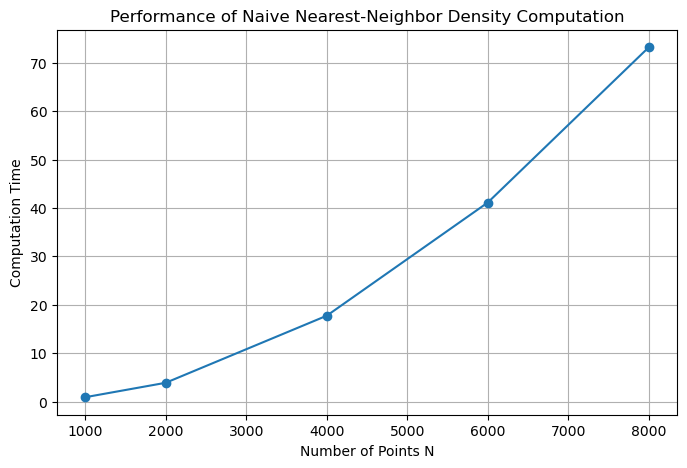

[0.8992812999058515,
 3.884291799971834,
 17.739240000024438,
 41.12496139993891,
 73.20533410017379]

In [6]:
compute_time_NN([1000, 2000, 4000, 6000, 8000])

# 2. Voxelization

In [7]:
def curvature_from_neighbors(X, Y, Z, neighbor_idx):
    xs = X[neighbor_idx]
    ys = Y[neighbor_idx]
    zs = Z[neighbor_idx]
    P = np.stack((xs, ys, zs), axis=1)
    
    if P.shape[0] < 3:
        return 0.0
    
    mean = P.mean(axis=0)
    P_centered = P - mean
    
    N = P_centered.shape[0]
    C = (P_centered.T @ P_centered) / (N - 1)
    
    eigenvalues, _ = eigh(C)
    eigenvalues = np.sort(eigenvalues)[::-1]
    
    lam1, lam2, lam3 = eigenvalues
    denom = lam1 + lam2 + lam3
    
    if denom <= 0:
        return 0.0
    
    return float(lam1 / denom)

class HashTable:
    def __init__(self, X, Y, Z):
        #Initialize hashtable
        self.X, self.Y, self.Z = X, Y, Z
        
        self.n_b, self.n_r, self.n_c = self.getBoxCounts(len(X))
        'Number of boxes:', self.n_b
        'Number of boxes in a row (or a column):', self.n_r

        self.X_norm, self.Y_norm, self.Z_norm = self.getNormalizedPoints()

        self.hashTable, self.pointsBox = self.getHashTable()

    def getBoxCounts(self, n_points):
        #Compute number of boxes and the number of boxes in rows and columns
        n_b = int(ceil(n_points ** (1/3)))
        n_r = int(ceil(n_b ** (1/3)))
        n_c = n_b
        return n_b, n_r, n_c

    def getNormalizedPoints(self):
        #Normalize points
        X_min, X_max = self.X.min(), self.X.max()
        Y_min, Y_max = self.Y.min(), self.Y.max()
        Z_min, Z_max = self.Z.min(), self.Z.max()

        X_norm = (self.X - X_min) / (X_max - X_min)
        Y_norm = (self.Y - Y_min) / (Y_max - Y_min)
        Z_norm = (self.Z - Z_min) / (Z_max - Z_min)

        return X_norm, Y_norm, Z_norm

    def hash(self, j_x, j_y, j_z):
        #Hash function
        return j_x + j_y * self.n_r + j_z * self.n_r * self.n_r

    def voxelCoords(self, x, y, z):
        #Compute voxel coordinates of a point
        j_x = int(0.99 * x * self.n_r)
        j_y = int(0.99 * y * self.n_r)
        j_z = int(0.99 * z * self.n_r)
        return j_x, j_y, j_z

    def getHashTable(self):
        #Create a hashtable of boxes
        table = defaultdict(list)
        boxes = []
        
        for i in range(len(self.X_norm)):
            j_x, j_y, j_z = self.voxelCoords(self.X_norm[i], self.Y_norm[i], self.Z_norm[i])
            key = self.hash(j_x, j_y, j_z)
            
            table[key].append(i)
            boxes.append(key)
        
        return table, boxes

    def drawVoxels(self, threshold = 1):
        #Draw voxels with at least 'threshold' points
        voxelGrid = self.getVoxelGrid(threshold)
        
        # Create figure
        fig = figure()
        ax = axes(projection = '3d')
        ax.set_aspect('equal') 
        
        #Create meshgrid
        X_min, X_max = self.X.min(), self.X.max()
        Y_min, Y_max = self.Y.min(), self.Y.max()
        Z_min, Z_max = self.Z.min(), self.Z.max()
        xedges = linspace(X_min, X_max, self.n_r + 1)
        yedges = linspace(Y_min, Y_max, self.n_r + 1)
        zedges = linspace(Z_min, Z_max, self.n_r + 1)
        
        VX, VY, VZ = meshgrid(xedges, yedges, zedges,  indexing="ij") 
        
        #Draw voxels
        ax.voxels(VX, VY, VZ, voxelGrid, edgecolor='k')
        
        show()
    
    def getVoxelGrid(self, threshold = 1):
        #Create voxel grid, each voxel is True if it contains at least 'threshold' points
        V = zeros((self.n_r, self.n_r, self.n_r), dtype=bool)
        
        for j_x in range(self.n_r):
            for j_y in range(self.n_r):
                for j_z in range(self.n_r):
                    if len(self.hashTable[self.hash(j_x, j_y, j_z)]) >= threshold:
                        V[j_x, j_y, j_z] = True

        return V

    def getNN(self, xq, yq, zq, idq, boxPointsIndices):
        #Find nearest point index and its distance
        dmin_2 = inf  #dmin squared as to avoid computing square roots
        idx = 0

        for i in boxPointsIndices:
            if idq == i:
                continue  #skip the query point itself

            dist_2 = (self.X[i] - xq) ** 2 + (self.Y[i] - yq) ** 2 + (self.Z[i] - zq) ** 2
            if dist_2 < dmin_2:
                dmin_2 = dist_2
                idx = i

        return idx, dmin_2

    def getNNForPoint(self, point_idx):
        xq, yq, zq = self.X[point_idx], self.Y[point_idx], self.Z[point_idx]
        
        box_key = self.pointsBox[point_idx]
        boxPointsIndices = self.hashTable[box_key]
        
        idx, dmin_2 = self.getNN(xq, yq, zq, point_idx, boxPointsIndices)
        
        if dmin_2 == inf:
            #No other points in the same box, search neighboring boxes
            j_x, j_y, j_z = self.voxelCoords(self.X_norm[point_idx], self.Y_norm[point_idx], self.Z_norm[point_idx])
            
            for dx in [-1, 0, 1]:
                for dy in [-1, 0, 1]:
                    for dz in [-1, 0, 1]:
                        if dx == 0 and dy == 0 and dz == 0:
                            continue    #skip the original box
                        
                        neighbor_jx = j_x + dx
                        neighbor_jy = j_y + dy
                        neighbor_jz = j_z + dz
                        
                        if 0 <= neighbor_jx < self.n_r and 0 <= neighbor_jy < self.n_r and 0 <= neighbor_jz < self.n_r:
                            neighbor_key = self.hash(neighbor_jx, neighbor_jy, neighbor_jz)
                            neighborBoxPointsIndices = self.hashTable[neighbor_key]
                            
                            if len(neighborBoxPointsIndices) > 0:
                                n_idx, n_dmin_2 = self.getNN(xq, yq, zq, point_idx, neighborBoxPointsIndices)
                                
                                if n_dmin_2 < dmin_2:
                                    dmin_2 = n_dmin_2
                                    idx = n_idx
    #Density
        return idx, dmin_2
    def getDensity(self):
        #Find nearest point using approximate nearest neighbor search using voxel grid
        distances = np.zeros(len(self.X))
        
        for i in range(len(self.X)):
            _, dmin_2 = self.getNNForPoint(i)
            distances[i] = sqrt(dmin_2)
        
        avg_distance = distances.mean()
        density = 1 / (avg_distance ** 3)
        return density
    #Curvatures    
    def getKNNForPoint(self, point_idx, k=30):
        xq = self.X[point_idx]
        yq = self.Y[point_idx]
        zq = self.Z[point_idx]

        j_x, j_y, j_z = self.voxelCoords(self.X_norm[point_idx],
                                         self.Y_norm[point_idx],
                                         self.Z_norm[point_idx])
    
        candidate_indices = []
    
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                for dz in [-1, 0, 1]:
                    nx = j_x + dx
                    ny = j_y + dy
                    nz = j_z + dz

                    if 0 <= nx < self.n_r and 0 <= ny < self.n_r and 0 <= nz < self.n_r:
                        key = self.hash(nx, ny, nz)
                        if key in self.hashTable:
                            candidate_indices.extend(self.hashTable[key])

        candidate_indices = [i for i in candidate_indices if i != point_idx]

        if len(candidate_indices) == 0:
            return []
    
        pts_x = self.X[candidate_indices]
        pts_y = self.Y[candidate_indices]
        pts_z = self.Z[candidate_indices]

        dx = pts_x - xq
        dy = pts_y - yq
        dz = pts_z - zq
        d2 = dx*dx + dy*dy + dz*dz

        order = np.argsort(d2)
        k_eff = builtins.min(k, len(order))

        return [candidate_indices[idx] for idx in order[:k_eff]]
        
    def getCurvatures(self, k=30):
        N = len(self.X)
        curvature = np.zeros(N)

        for i in range(N):
            neighbors = self.getKNNForPoint(i, k=k)

            if len(neighbors) < 3:
                curvature[i] = 0.0
                continue

            curvature[i] = curvature_from_neighbors(self.X, self.Y, self.Z, neighbors)

        return curvature


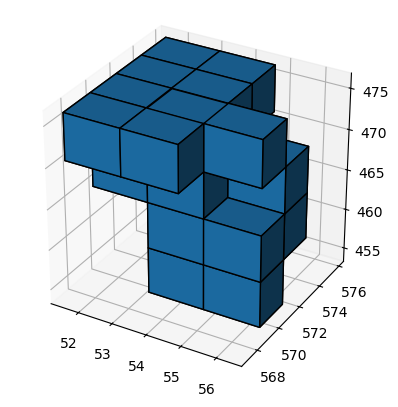

In [8]:
hashTable = HashTable(X, Y, Z)
hashTable.drawVoxels(275)

In [30]:
'Density using approximate nearest neighbor distance (ANN) with voxels:', hashTable.getDensity()


('Density using approximate nearest neighbor distance (ANN) with voxels:',
 np.float64(5507.542382287587))

In [31]:
hashTableCurvs = hashTable.getCurvatures()
'Curvature for all points', hashTableCurvs

('Curvature for all points',
 array([0.02019061, 0.01370536, 0.02703648, ..., 0.14296777, 0.13848764,
        0.1177637 ], shape=(25737,)))

## Time computing for Voxel-Based Density and Curvature Computation

In [10]:
def compute_time(sample_sizes, repeats=1):
   
    times = []

    for N in sample_sizes:
        f"Measuring N = {N}..."

        # generate random 3D points
        X = np.random.rand(N)
        Y = np.random.rand(N)
        Z = np.random.rand(N)

        # build voxel hash table (not included in timing)
        ht = HashTable(X, Y, Z)

        # measure time
        t_total = 0.0
        for _ in range(repeats):
            t0 = perf_counter()
            ht.getDensity()
            ht.getCurvatures()
            t1 = perf_counter()
            t_total += (t1 - t0)

        avg_time = t_total / repeats
        times.append(avg_time)

    # plot
    figure(figsize=(8, 5))
    plot(sample_sizes, times, marker='o')
    xlabel("Number of Points N")
    ylabel("Computation Time (s)")
    title("Performance of Voxel-Based Density + Curvature Computation")
    grid(True)
    show()

    return times

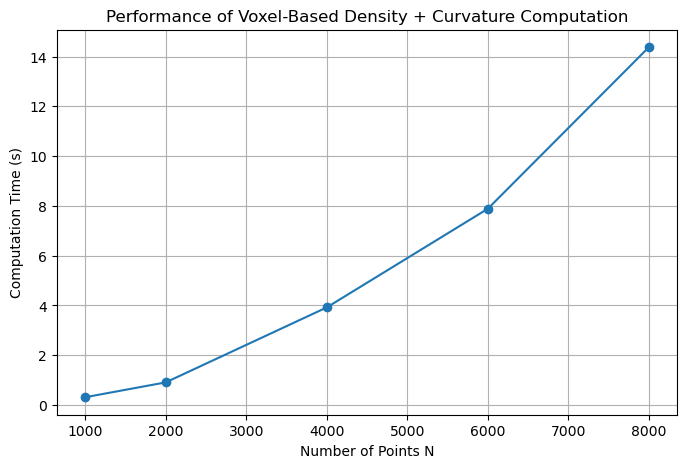

[0.3123764998745173,
 0.9088073000311852,
 3.92082059988752,
 7.885006800061092,
 14.376567000057548]

In [11]:
compute_time([1000, 2000, 4000, 6000, 8000])

## Effect of Voxel Grid Resolution on Runtime - visualisation

In [12]:
class HashTableFixedNr(HashTable):
    def __init__(self, X, Y, Z, n_r):
        self.X = X
        self.Y = Y
        self.Z = Z
        self.n_r = n_r
        self.n_b = n_r ** 3
        self.n_c = self.n_b
        self.X_norm, self.Y_norm, self.Z_norm = self.getNormalizedPoints()
        self.hashTable, self.pointsBox = self.getHashTable()

def voxel_vs_grid_size(N, n_r_values, repeats=1):
    times = []

    # pevný point cloud
    X = np.random.rand(N)
    Y = np.random.rand(N)
    Z = np.random.rand(N)

    for n_r in n_r_values:
        f"n_r = {n_r}"

        ht = HashTableFixedNr(X, Y, Z, n_r)

        t_total = 0.0
        for _ in range(repeats):
            t0 = perf_counter()
            ht.getDensity()
            ht.getCurvatures()
            t1 = perf_counter()
            t_total += (t1 - t0)

        times.append(t_total / repeats)

    figure(figsize=(8, 5))
    plot(n_r_values, times, marker='o')
    xlabel("Voxel grid size n_r")
    ylabel("Computation time (s)")
    title("Voxel method: density + curvature vs. voxel size")
    grid(True)
    show()

    return times

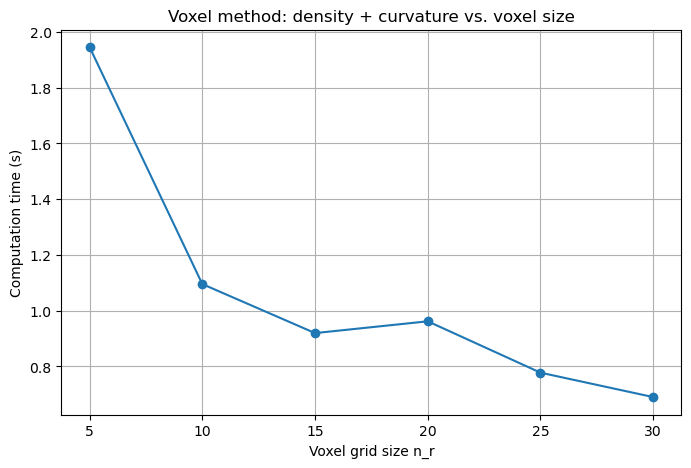

[1.9458389000501484,
 1.0955936999525875,
 0.9197821000125259,
 0.9620299998205155,
 0.777805200079456,
 0.6902147999498993]

In [13]:
voxel_vs_grid_size(
    N=5000,
    n_r_values=[5, 10, 15, 20, 25, 30]
)

## Visualization of Point Cloud Curvature Using Voxel Method 

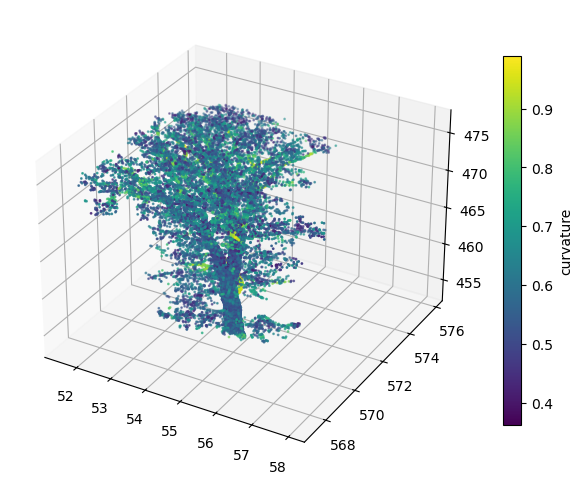

In [14]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

p = ax.scatter(X, Y, Z, c=hashTableCurvs, s=1, cmap='viridis')
fig.colorbar(p, ax=ax, label='curvature', shrink = 0.8)

plt.show()


# 3. Accelerated search using a kd-tree.

In [15]:
class KDNode:

    def __init__(self, point=None, axis=None, left=None, right=None, point_index=None):
    
        self.point = point
        self.axis = axis
        self.left = left
        self.right = right
        self.point_index = point_index
        
class KDTree:

    def __init__(self, data):
        
        self.data = np.array(data)  # Ensure data is a NumPy array
        self.root = self._build_tree(np.array(range(len(self.data[0]))), 0)

    def _build_tree(self, idxs, depth):
        if len(idxs) == 0:
            return None
        
        axis = depth % 3

        sorted_idxs = idxs[np.argsort(self.data[axis, idxs])]
        median_idx = len(sorted_idxs) // 2

        actuall_idx = sorted_idxs[median_idx]

        return KDNode(
            point=self.data[:, actuall_idx].copy(),
            axis=axis,
            left=self._build_tree(sorted_idxs[:median_idx], depth + 1),
            right=self._build_tree(sorted_idxs[median_idx + 1:], depth + 1),
            point_index=sorted_idxs[median_idx]
        )
    #density
    def getDensity(self):
        distances = np.zeros(len(self.data[0]))

        for query_idx in range(len(self.data[0])):
            query = self.data[:, query_idx]
            
            best, best_dist_2 = self.getNNForPoint(query_idx)
            
            distances[query_idx] = sqrt(best_dist_2)

        avg_distance = distances.mean()
        density = 1 / (avg_distance ** 3)
        return density

    def getNNForPoint(self, point_idx):
        query = self.data[:, point_idx]
        best, best_dist_2 = self.getNN(self.root, query, point_idx, None, float('inf'))
        return best, best_dist_2

    def getNN(self, node, q_point, q_idx, best, best_dist_2):
        if node is None:
            return best, best_dist_2

        point = node.point
        axis = node.axis

        if node.point_index != q_idx:
            dist_2 = (point[0] - q_point[0]) ** 2 + (point[1] - q_point[1]) ** 2 + (point[2] - q_point[2]) ** 2
            if dist_2 < best_dist_2:
                best_dist_2 = dist_2
                best = node

        diff = q_point[axis] - point[axis]
        if diff < 0:
            close, far = (node.left, node.right)
        else:
            close, far = (node.right, node.left)

        best, best_dist_2 = self.getNN(close, q_point, q_idx, best, best_dist_2)

        if diff ** 2 < best_dist_2:
            return self.getNN(far, q_point, q_idx, best, best_dist_2)

        return best, best_dist_2
    #curvature    
    def getKNNForPoint(self, point_idx, k):
        # Returns the indices and distances to the k nearest neighbors for the point point_idx

        q_point = self.data[:, point_idx]
        heap = []  # max-heap, we will store (-dist2, index)
        self._getKNN(self.root, q_point, point_idx, k, heap)

        neighbors = []
        for neg_dist2, idx in heap:
            neighbors.append((idx, -neg_dist2))

        # sort neighbors by distance (ascending)
        neighbors.sort(key=lambda x: x[1])

        indices = np.array([n[0] for n in neighbors], dtype=int)
        dists2 = np.array([n[1] for n in neighbors], dtype=float)
        return indices, dists2
    def _getKNN(self, node, q_point, q_idx, k, heap):
         # Recursive search for k nearest neighbors in the KD-tree. heap: max-heap containing items (-dist2, index)
        if node is None:
            return

        point = node.point
        axis = node.axis

        # Do not compute the distance to the query point itself
        if node.point_index != q_idx:
            dist2 = ((point[0] - q_point[0]) ** 2 +
                     (point[1] - q_point[1]) ** 2 +
                     (point[2] - q_point[2]) ** 2)

            if len(heap) < k:
                heapq.heappush(heap, (-dist2, node.point_index))
            else:
                if dist2 < -heap[0][0]:
                    heapq.heapreplace(heap, (-dist2, node.point_index))

        # Choose the nearer and farther subtree
        diff = q_point[axis] - point[axis]
        if diff < 0:
            close, far = node.left, node.right
        else:
            close, far = node.right, node.left

        # First explore the closer subtree
        self._getKNN(close, q_point, q_idx, k, heap)

        # Then explore the farther subtree if it makes sense
        if len(heap) < k or diff ** 2 < -heap[0][0]:
            self._getKNN(far, q_point, q_idx, k, heap)
    def getAllKNN(self, k=30):
        #  For each point, returns an array of indices of its k nearest neighbors. Output: ndarray of shape (N, k)
        N = self.data.shape[1]
        knn_indices = np.zeros((N, k), dtype=int)

        for i in range(N):
            indices, dists2 = self.getKNNForPoint(i, k)
            knn_indices[i, :] = indices

        return knn_indices
    def _get_neighbors_matrix(self, neighbor_indices):
        #Returns the matrix of neighbors (k × 3) for the given indices
        neighbors = self.data[:, neighbor_indices].T  # shape (k, 3)
        return neighbors
    def _center_neighbors(self, neighbors):
        #neighbors: (k × 3)
        #Returns the centered neighbors and the centroid.
        
        center = neighbors.mean(axis=0)      # (3,)
        residuals = neighbors - center       # (k, 3)
        return residuals, center
    def _covariance_matrix(self, residuals):
        # residuals: (k × 3)
        # Returns the 3×3 covariance matrix.
        k = residuals.shape[0]
        C = (residuals.T @ residuals) / k   # (3 x 3)
        return C
    def _eigenvalues_from_cov(self, C):
        # Returns the eigenvalues sorted in ascending order.
        w, v = np.linalg.eigh(C)  # pro symetrické matice
        w = np.sort(w)            # λ1 <= λ2 <= λ3
        return w
    def curvature_for_point(self, point_idx, k=30):
        # Computes curvature κ for a single point using PCA on its k nearest neighbors.
        # 1) k nearest neighbors
        neighbor_indices, _ = self.getKNNForPoint(point_idx, k)

        # 2) neighbor matrix (k × 3)
        neighbors = self._get_neighbors_matrix(neighbor_indices)

        # 3) centering
        residuals, center = self._center_neighbors(neighbors)

        # 4) covariance matrix
        C = self._covariance_matrix(residuals)

        # 5) eigenvalues
        lambdas = self._eigenvalues_from_cov(C)
        lam_sum = lambdas.sum()

        if lam_sum <= 0:
            return 0.0  # degenerated case

        kappa = lambdas[0] / lam_sum
        return kappa
    def getCurvatures(self, k=30):
        # Computes curvature for all points in the point cloud.
        # Returns an array of shape (N,) – the curvature for each point
        N = self.data.shape[1]
        curvatures = np.zeros(N, dtype=float)

        for i in range(N):
            curvatures[i] = self.curvature_for_point(i, k)

        return curvatures


In [16]:
kdTree = KDTree([X, Y, Z])

In [32]:
'Density using K-D tree:', kdTree.getDensity()


('Density using K-D tree:', np.float64(6060.374340762823))

In [ ]:
'Curvature of every point using KD tree:', kdTree.getCurvatures()

## Time computing for KD-Tree Density and Curvature Computation

In [18]:
def compute_time_kdtree_density_curvature(sample_sizes, repeats=1):
    
    times = []

    for N in sample_sizes:
        f"Measuring N = {N}..."

        # generate random 3D points
        X = np.random.rand(N)
        Y = np.random.rand(N)
        Z = np.random.rand(N)

        # KDTree expects data of shape (3, N)
        data = np.vstack((X, Y, Z))
        kdt = KDTree(data)

        # measure time: density + curvature
        t_total = 0.0
        for _ in range(repeats):
            t0 = perf_counter()
            kdt.getDensity()
            kdt.getCurvatures()
            t1 = perf_counter()
            t_total += (t1 - t0)

        avg_time = t_total / repeats
        times.append(avg_time)

    # visualization of results
    figure(figsize=(8, 5))
    plot(sample_sizes, times, marker='o')
    xlabel("Number of Points N")
    ylabel("Computation Time (s)")
    title("Performance of KD-Tree Density + Curvature Computation")
    grid(True)
    show()

    return times

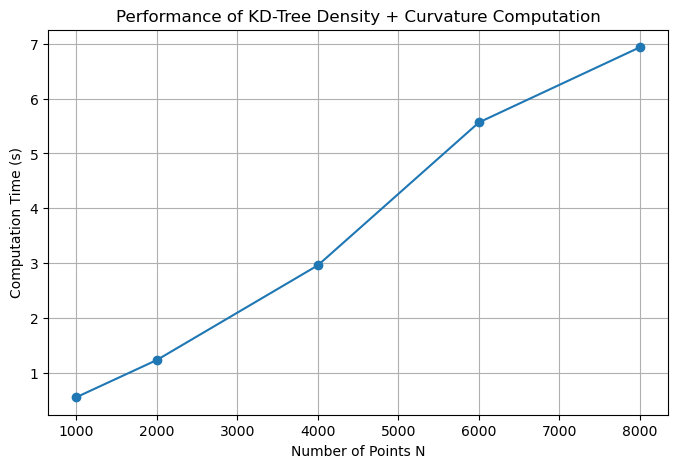

[0.554527600063011,
 1.2332294001244009,
 2.960295599885285,
 5.5660928001161665,
 6.937473400030285]

In [19]:
compute_time_kdtree_density_curvature([1000, 2000, 4000, 6000, 8000])

## Visualization of Point Cloud Curvature Using KD-Tree

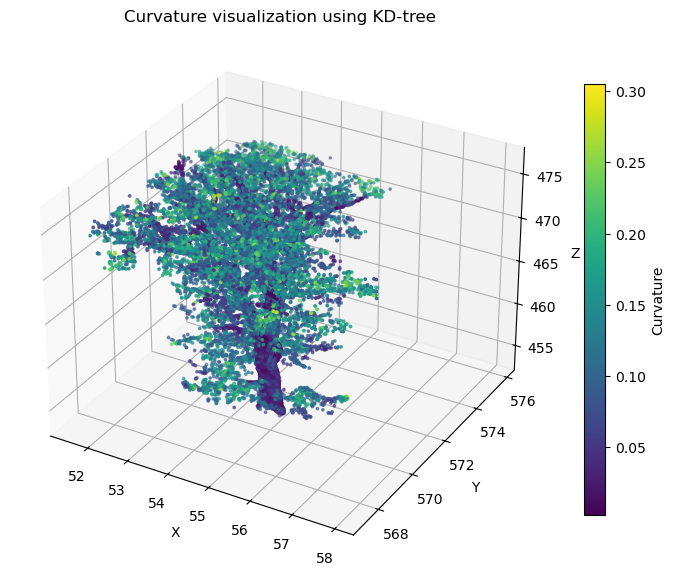

In [20]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Extract points from KDTree
X = kdTree.data[0]
Y = kdTree.data[1]
Z = kdTree.data[2]

curvs = kdTree.getCurvatures()   # Curvature for every point

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

p = ax.scatter(X, Y, Z, c=curvs, s=3, cmap='viridis')  # s=3 - bigger than 1
fig.colorbar(p, ax=ax, label='Curvature', shrink = 0.8)

ax.set_title("Curvature visualization using KD-tree")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

# 4.  Accelerated search using an Octree

In [21]:
import numpy as np

class OctreeNode:
    def __init__(self, points_idx, bbox, depth=0):
        self.points_idx = points_idx
        self.bbox = bbox
        self.children = [None]*8
        self.is_leaf = True
        self.depth = depth

class Octree:
    def __init__(self, data, max_points=100, max_depth=10):
        self.data = np.array(data)
        self.max_points = max_points
        self.max_depth = max_depth
        self.root = self.build_octree(list(range(len(self.data[0]))),
                                 [self.data[0].min(), self.data[0].max(),
                                  self.data[1].min(), self.data[1].max(),
                                  self.data[2].min(), self.data[2].max()])

    def build_octree(self, points_idx, bbox, depth=0):
        node = OctreeNode(points_idx, bbox, depth)
        
        if len(points_idx) <= self.max_points or depth >= self.max_depth:
            return node  # leaf
        
        node.is_leaf = False
        xmin, xmax, ymin, ymax, zmin, zmax = bbox
        xmid = (xmin + xmax)/2
        ymid = (ymin + ymax)/2
        zmid = (zmin + zmax)/2
        
        # Assign points to octants
        octant_points = [[] for _ in range(8)]
        for idx in points_idx:
            x, y, z = self.data[:, idx]
            oct_idx = 0
            if x >= xmid:
                oct_idx += 1
            if y >= ymid:
                oct_idx += 2
            if z >= zmid:
                oct_idx += 4
            octant_points[oct_idx].append(idx)
        
        # Define new bounding boxes for children
        for i in range(8):
            if not octant_points[i]:
                continue

            x0 = xmin if (i % 2) == 0 else xmid
            x1 = xmid if (i % 2) == 0 else xmax
            y0 = ymin if (i % 4 // 2) == 0 else ymid
            y1 = ymid if (i % 4 // 2) == 0 else ymax
            z0 = zmin if (i // 4) == 0 else zmid
            z1 = zmid if (i // 4) == 0 else zmax
            
            child_bbox = [x0, x1, y0, y1, z0, z1]
            node.children[i] = self.build_octree(octant_points[i], child_bbox)
        
        return node

    def getDensity(self):
        distances = np.zeros(len(self.data[0]))

        for query_idx in range(len(self.data[0])):
            best, best_dist_2 = self.getNNForPoint(query_idx)
            
            distances[query_idx] = sqrt(best_dist_2)

        avg_distance = distances.mean()
        density = 1 / (avg_distance ** 3)
        return density
    
    def getNNForPoint(self, point_idx):
        query = self.data[:, point_idx]
        best, best_dist_2 = self.getNN(self.root, query, point_idx, None, float('inf'))
        return best, best_dist_2
            
    def dist_to_box2(self, p, box):
        dx = max([box[0] - p[0], 0, p[0] - box[1]])
        dy = max([box[2] - p[1], 0, p[1] - box[3]])
        dz = max([box[4] - p[2], 0, p[2]- box[5]])
        return dx*dx + dy*dy + dz*dz

    def getNN(self, node, q_point, q_idx, best, best_dist_2):
        if node is None:
            return best, best_dist_2
        
        if node.is_leaf:
            for idx in node.points_idx:
                if idx == q_idx:
                    continue  #skip the query point itself
                
                point = self.data[:, idx]
                dist_2 = (point[0] - q_point[0]) ** 2 + (point[1] - q_point[1]) ** 2 + (point[2] - q_point[2]) ** 2
                if dist_2 < best_dist_2:
                    best_dist_2 = dist_2
                    best = idx
            return best, best_dist_2
        
        xmin, xmax, ymin, ymax, zmin, zmax = node.bbox
        xmid = (xmin + xmax)/2
        ymid = (ymin + ymax)/2
        zmid = (zmin + zmax)/2
        diff_x = q_point[0] - xmid
        diff_y = q_point[1] - ymid
        diff_z = q_point[2] - zmid

        # Determine the primary node (the one, where the point is located)
        primary = 0
        for i in range(8):
            if node.children[i] is None:
                continue
            dist_to_box_2 = self.dist_to_box2(q_point, node.children[i].bbox)
            if dist_to_box_2 == 0:
                primary = i
                break

        # Search primary node first
        best, best_dist_2 = self.getNN(node.children[primary], q_point, q_idx, best, best_dist_2)

        # Check other nodes if necessary
        for i in range(8):
            if i == primary or node.children[i] is None:
                continue
            
            dist_to_box = self.dist_to_box2(q_point, node.children[i].bbox)
            
            if dist_to_box < best_dist_2:
                new_best, new_best_dist_2 = self.getNN(node.children[i], q_point, q_idx, best, best_dist_2)
                if new_best_dist_2 < best_dist_2:
                    best_dist_2 = new_best_dist_2
                    best = new_best

        return best, best_dist_2

#### Curvature

In [22]:
#curvature for nearest neighbors
def curvature_from_neighbors(X, Y, Z, neighbor_idx):
     # Select neighboring points
    xs = X[neighbor_idx]
    ys = Y[neighbor_idx]
    zs = Z[neighbor_idx]
    points = np.column_stack((xs, ys, zs))

     # We need at least 3 points
    if len(points) < 3:
        return 0.0

    # Subtract the mean
    mean = points.mean(axis=0)
    centered = points - mean

    # Covariance matrix
    cov = np.dot(centered.T, centered) / (points.shape[0] - 1)

    # Eigenvalues
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # lambda1 is the smallest 
    lambda1 = eigenvalues[0]
    lambda2 = eigenvalues[1]
    lambda3 = eigenvalues[2]

    # Curvature calculation
    curvature = lambda1 / (lambda1 + lambda2 + lambda3)
    return curvature

In [23]:
class Octree(Octree):

    def get_dist_2(self, id_a, id_b):
        X = self.data[0]
        Y = self.data[1]
        Z = self.data[2]

        dx = X[id_a] - X[id_b]
        dy = Y[id_a] - Y[id_b]
        dz = Z[id_a] - Z[id_b]
        d = dx*dx + dy*dy + dz*dz
        return d
    
    def collect_indices(self, node, point, point_id, candidates, k=30):
        if node is None:
            return
        
        box_dist_2 = self.dist_to_box2(point, node.bbox)

        if len(candidates) == k and box_dist_2 > candidates[-1][0]: # the furthest candidate is in the last position in the array
            return
        
        if node.is_leaf:
            for id in node.points_idx:
                if id == point_id:
                    continue
                d_2 = self.get_dist_2(id, point_id)
                candidates.append((d_2, id))
            candidates.sort(key=lambda x: x[0])
            candidates[:] = candidates[:k]
            return
        
        child_list = []

        for child in node.children:
            if child is None:
                continue
            child_dist_2 = self.dist_to_box2(point, child.bbox)
            child_list.append((child_dist_2, child))
        
        child_list.sort(key=lambda x: x[0])

        for (child_dist_2, child_node) in child_list:
            if len(candidates) == k and child_dist_2 > candidates[-1][0]: # the furthest candidates is in the last position in the array
                break
            self.collect_indices(child_node, point, point_id, candidates, k)

    def query_knn(self, point, point_id, k=30):
       
        # 1) collect candidates
        candidates = []
        self.collect_indices(self.root, point, point_id, candidates=candidates, k=k)

         # 2) return k nearest neighbor indices
        neighbor_idx = [idx for (d, idx) in candidates[:k]]

        return neighbor_idx
    def getCurvatures(self, k=30):

       # Computes curvature for every point in the point cloud using the Octree.

        X = self.data[0]
        Y = self.data[1]
        Z = self.data[2]
        N = len(X)

        curvatures = np.zeros(N)

        for i in range(N):
            point = (X[i], Y[i], Z[i])

             # find neighbors
            neighbors = self.query_knn(point, i, k=k)

            # compute curvature
            curvatures[i] = curvature_from_neighbors(X, Y, Z, neighbors)
            
            # progress bar
            if i % 500 == 0:
                "Zpracováno", i, "bodů z", N

        return curvatures

In [24]:
octree = Octree([X, Y, Z], max_points=100)

In [25]:
'Density using Octree:', octree.getDensity()

('Density using Octree:', np.float64(6060.374340762823))

In [26]:
'Curvature using Octree:', octree.getCurvatures()

('Curvature using Octree:',
 array([0.02019061, 0.01370536, 0.02703648, ..., 0.14296777, 0.13848764,
        0.1177637 ], shape=(25737,)))

## Visualization of Point Cloud Curvature using Octree method

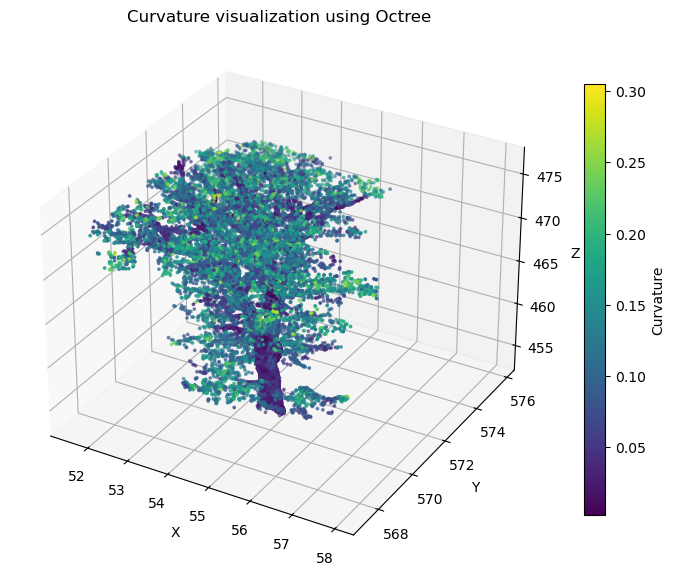

In [27]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Extract points from Octree
X = octree.data[0]
Y = octree.data[1]
Z = octree.data[2]

curvs = octree.getCurvatures()   # Curvature for every point

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

p = ax.scatter(X, Y, Z, c=curvs, s=3, cmap='viridis')
fig.colorbar(p, ax=ax, label='Curvature', shrink=0.8)

ax.set_title("Curvature visualization using Octree")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

## Time computing for Octree Density and Curvature Computation

In [28]:
def compute_time_octree_density_curvature(sample_sizes, repeats=1):
    
    times = []

    for N in sample_sizes:
        f"Measuring N = {N}..."

        # generate random 3D points
        X = np.random.rand(N)
        Y = np.random.rand(N)
        Z = np.random.rand(N)

        # Octree expects data of shape (3, N)
        data = np.vstack((X, Y, Z))
        kdt = Octree(data, max_points=100)

        # measure time: density + curvature
        t_total = 0.0
        for _ in range(repeats):
            t0 = perf_counter()
            octree.getDensity()
            octree.getCurvatures()
            t1 = perf_counter()
            t_total += (t1 - t0)

        avg_time = t_total / repeats
        times.append(avg_time)

    # visualization of results
    figure(figsize=(8, 5))
    plot(sample_sizes, times, marker='o')
    xlabel("Number of Points N")
    ylabel("Computation Time (s)")
    title("Performance of Octree Density + Curvature Computation")
    grid(True)
    show()

    return times

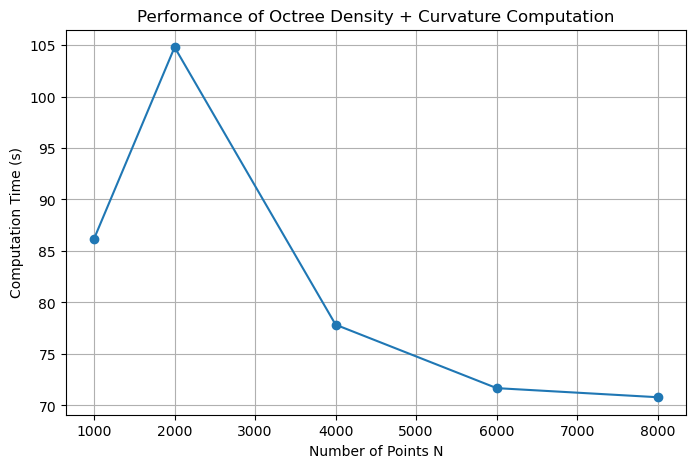

[86.19310960010625,
 104.78676759987138,
 77.84065749985166,
 71.68117480003275,
 70.79841639986262]

In [29]:
compute_time_octree_density_curvature([1000, 2000, 4000, 6000, 8000])